In [ ]:
%pip install torch torchvision xgboost scikit-learn opencv-python numpy matplotlib seaborn joblib

In [7]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier,BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Using: cpu
cardboard : 404 images
glass : 502 images
metal : 411 images
paper : 595 images
plastic : 483 images
trash : 590 images
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


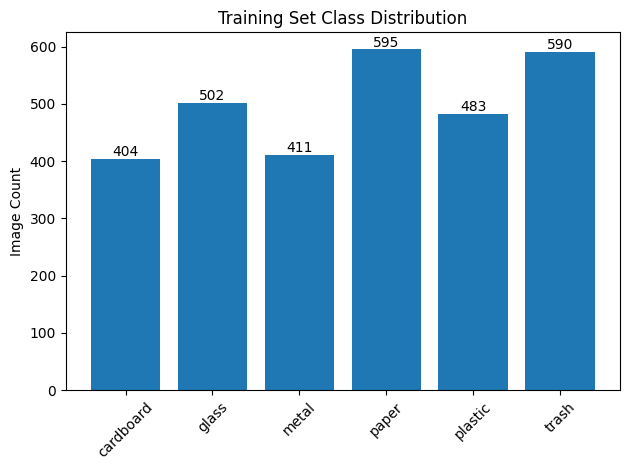

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

root = "dataset/"
for folder in os.listdir(root):
    path = os.path.join(root, folder)
    print(folder, ":", len(os.listdir(path)), "images")

dataset = datasets.ImageFolder(root)
print(dataset.class_to_idx)

# Plot class distribution
counts = [len(os.listdir(os.path.join(root, cls))) for cls in dataset.classes]
bars = plt.bar(dataset.classes, counts)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count), ha='center')
plt.xticks(rotation=45)
plt.ylabel("Image Count")
plt.title("Training Set Class Distribution")
plt.tight_layout()
plt.show()

In [9]:
torch.manual_seed(42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(20),
    transforms.RandomVerticalFlip(20),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder("dataset/", transform=transform)

train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print("Images leak:", len(set(train_dataset.indices).intersection(set(test_dataset.indices))))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Images leak: 0
Train size: 2384
Test size: 596


In [10]:
#Load CNN 
mobilenet = models.mobilenet_v2(pretrained=True).to(device)
mobilenet.classifier = nn.Identity()
for param in mobilenet.parameters():
    param.requires_grad = False
mobilenet.eval()

#Extra Feature extraction
def edge_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges) / edges.size
    return [edge_density]

mobilenet = models.mobilenet_v2(pretrained=True).to(device)
mobilenet.classifier = nn.Identity()
for param in mobilenet.parameters():
    param.requires_grad = False
mobilenet.eval()

def feature_extraction(loader, model):
    all_features, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            cnn_feat = model(images).cpu()   # shape: (batch, 1280)
            all_features.append(cnn_feat)
            all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

print("Extracting features...")
train_features, train_labels = feature_extraction(train_loader, mobilenet)
test_features,  test_labels  = feature_extraction(test_loader,  mobilenet)

X_train, y_train = train_features.numpy(), train_labels.numpy()
X_test,  y_test  = test_features.numpy(),  test_labels.numpy()

print("Train features shape:", X_train.shape)
print("Test  features shape:", X_test.shape)

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extracting features...
Train features shape: (2384, 1280)
Test  features shape: (596, 1280)


## Model Registry

To add a new model, just add one entry to the `MODELS` dict below and re-run from this cell onwards.

In [11]:
#Train mode (We can train more than one model)
MODELS = {
    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        use_label_encoder=False,
        eval_metric="mlogloss"
    ),
    "Soft Voting": VotingClassifier(
        estimators=[
            ("xgb", XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss")),
            ("rf",  RandomForestClassifier(n_estimators=100, random_state=42)),
            ("lr",  LogisticRegression(max_iter=5000, random_state=42)),
        ],
        voting="soft"
    ),

"Stacking": StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("rf",  RandomForestClassifier(n_estimators=100, random_state=42)),
        ("dt",  DecisionTreeClassifier(max_depth=10, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    cv=5
),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
}

print(f"Will train {len(MODELS)} models:", list(MODELS.keys()))

Will train 4 models: ['XGBoost', 'Soft Voting', 'Stacking', 'Bagging']


In [12]:
results = {}  # stores {name: {"preds": ..., "accuracy": ..., "report": ...}}

for name, clf in MODELS.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, target_names=dataset.classes, output_dict=True)
    results[name] = {"preds": preds, "accuracy": acc, "report": report, "clf": clf}
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=dataset.classes))

print("\n✅ All models trained!")


Training: XGBoost


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7634
              precision    recall  f1-score   support

   cardboard       0.95      0.68      0.79        81
       glass       0.73      0.77      0.75        98
       metal       0.80      0.79      0.80        82
       paper       0.77      0.82      0.80       125
     plastic       0.67      0.66      0.67        80
       trash       0.74      0.80      0.77       130

    accuracy                           0.76       596
   macro avg       0.78      0.75      0.76       596
weighted avg       0.77      0.76      0.76       596


Training: Soft Voting


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:59:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7584
              precision    recall  f1-score   support

   cardboard       0.90      0.69      0.78        81
       glass       0.74      0.78      0.76        98
       metal       0.76      0.79      0.78        82
       paper       0.77      0.78      0.78       125
     plastic       0.72      0.70      0.71        80
       trash       0.72      0.78      0.75       130

    accuracy                           0.76       596
   macro avg       0.77      0.75      0.76       596
weighted avg       0.76      0.76      0.76       596


Training: Stacking
Accuracy: 0.7248
              precision    recall  f1-score   support

   cardboard       0.92      0.67      0.77        81
       glass       0.67      0.69      0.68        98
       metal       0.74      0.63      0.68        82
       paper       0.79      0.78      0.79       125
     plastic       0.55      0.70      0.62        80
       trash       0.74      0.80      0.77       130

    accuracy           

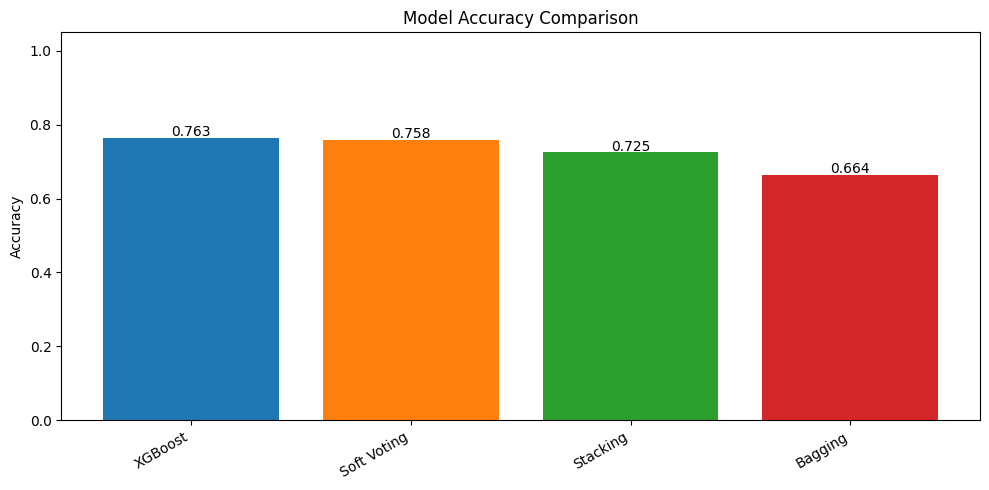


Model                       Accuracy
-------------------------------------
XGBoost                       0.7634
Soft Voting                   0.7584
Stacking                      0.7248
Bagging                       0.6644


In [13]:
# Charts 
names = list(results.keys())
accs  = [results[n]["accuracy"] for n in names]

colors = plt.cm.tab10.colors
plt.figure(figsize=(10, 5))
bars = plt.bar(names, accs, color=colors[:len(names)])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{acc:.3f}", ha="center", fontsize=10)
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

# ── Summary Table ──
print(f"\n{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
for name, acc in sorted(zip(names, accs), key=lambda x: -x[1]):
    print(f"{name:<25} {acc:>10.4f}")

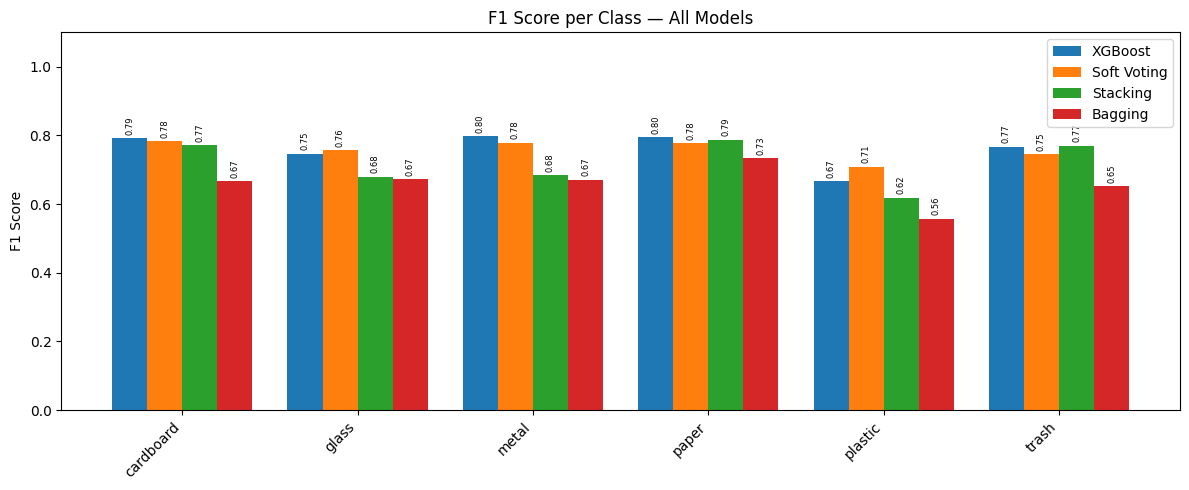

In [14]:
n_models  = len(results)
n_classes = len(dataset.classes)
x = np.arange(n_classes)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, res) in enumerate(results.items()):
    f1s  = [res["report"][cls]["f1-score"] for cls in dataset.classes]
    bars = ax.bar(x + i * width - 0.4 + width/2, f1s, width, label=name)
    for bar, f1 in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{f1:.2f}", ha="center", va="bottom", fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score per Class — All Models")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

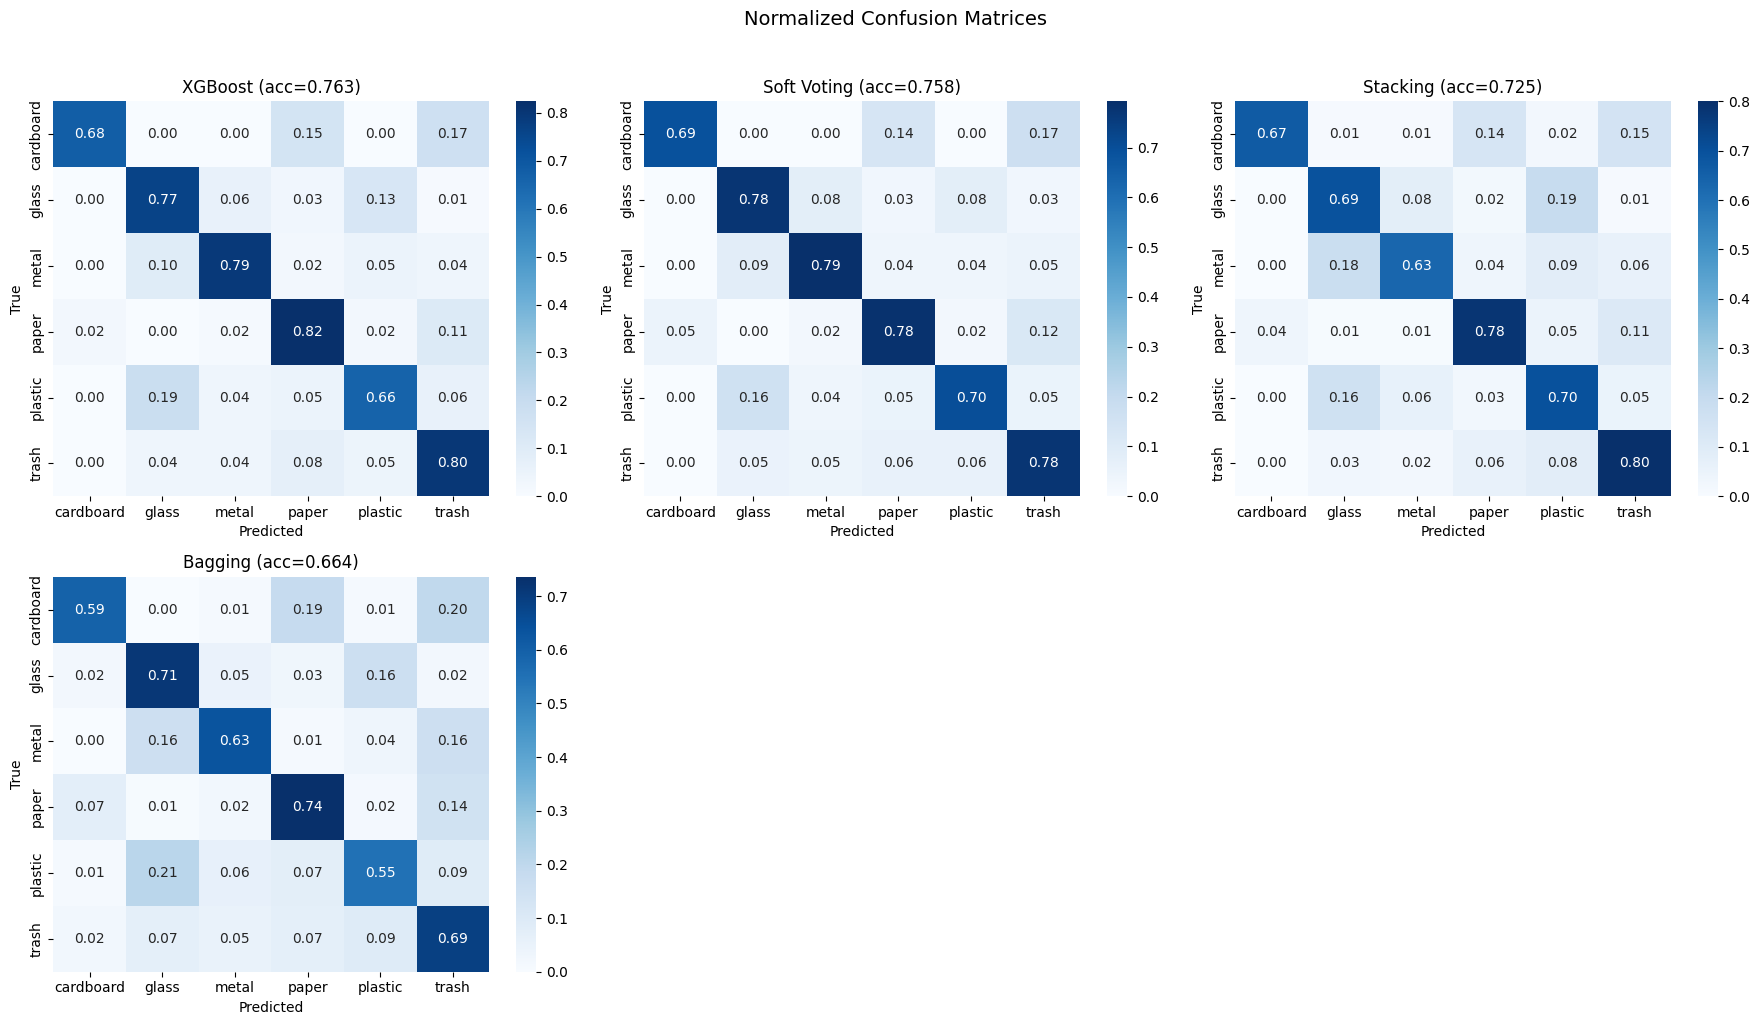

In [15]:
#Confusion Matrices
n = len(results)
cols = min(3, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).flatten() if n > 1 else [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=dataset.classes,
                yticklabels=dataset.classes, ax=ax)
    ax.set_title(f"{name} (acc={res['accuracy']:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Hide unused axes
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Normalized Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_19128\3685521151.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
C:\Users\USER\AppData\Local\Temp\ipykernel_19128\3685521151.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
C:\Users\USER\AppData\Local\Temp\ipykernel_19128\3685521151.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
C:\Users\USER\AppData\Local\Temp\ipykernel_19128\3685521151.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dataset.classe

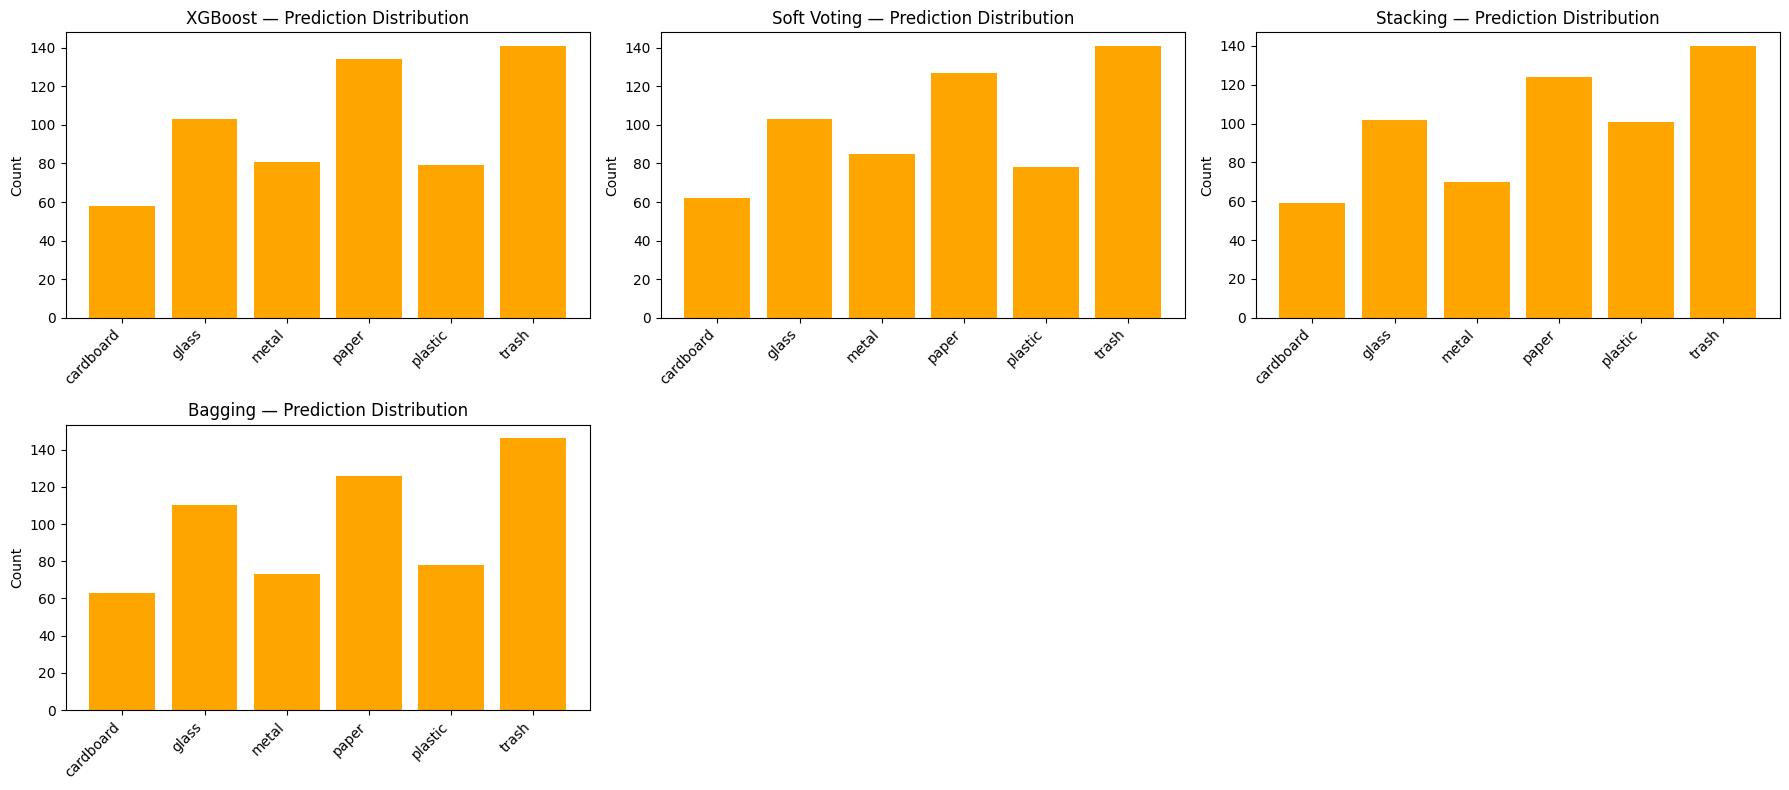

In [16]:
#Prediction Distribution
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).flatten() if n > 1 else [axes]

for ax, (name, res) in zip(axes, results.items()):
    pred_counts = np.bincount(res["preds"], minlength=len(dataset.classes))
    ax.bar(dataset.classes, pred_counts, color="orange")
    ax.set_title(f"{name} — Prediction Distribution")
    ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
    ax.set_ylabel("Count")

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [59]:
#Saving Model
best_name = max(results, key=lambda n: results[n]["accuracy"])
best_clf  = results[best_name]["clf"]

os.makedirs("model", exist_ok=True)
joblib.dump(best_clf,       "model/classifier.pkl")
joblib.dump(dataset.classes,"model/classes.pkl")

print(f"✅ Saved best model: {best_name}")
print(f"   Accuracy: {results[best_name]['accuracy']:.4f}")
print(f"   Saved to: model/classifier.pkl")

# ── Or save a specific model ──
# joblib.dump(results["XGBoost"]["clf"], "model/classifier.pkl")

✅ Saved best model: XGBoost
   Accuracy: 0.7634
   Saved to: model/classifier.pkl


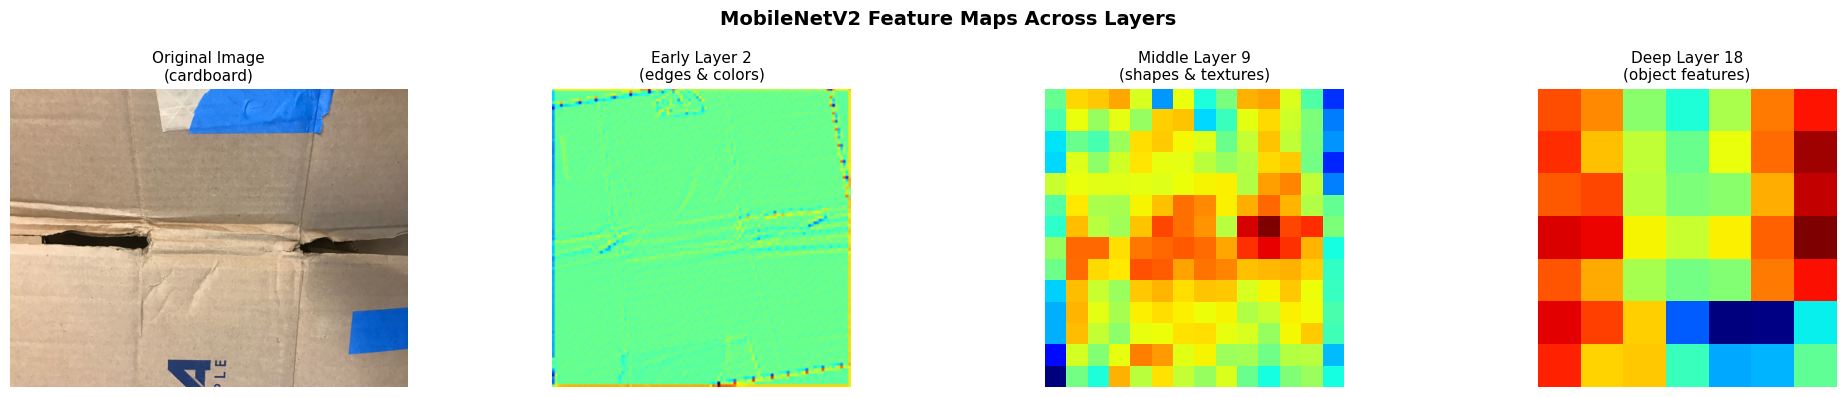

Sample class: cardboard
Early layers detect simple patterns like edges and colors
Middle layers detect shapes and textures
Deep layers detect high-level object features used for classification


In [52]:

# ── Multi-layer CNN Feature Visualization ──
sample_path, sample_label = random.choice(dataset.samples)
class_name = dataset.classes[sample_label]

pil_img = Image.open(sample_path).convert("RGB")
img_tensor = transform(pil_img).unsqueeze(0).to(device)

# Layers to visualize: early, middle, deep
layer_indices = [2, 9, 18]
layer_names   = ["Early Layer 2\n(edges & colors)", "Middle Layer 9\n(shapes & textures)", "Deep Layer 18\n(object features)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Original image
axes[0].imshow(pil_img)
axes[0].set_title(f"Original Image\n({class_name})", fontsize=11)
axes[0].axis("off")

# Feature maps at each layer
for i, (idx, name) in enumerate(zip(layer_indices, layer_names)):
    with torch.no_grad():
        conv = torch.nn.Sequential(*list(mobilenet.features.children())[:idx])
        fmap = conv(img_tensor).cpu()

    heatmap = fmap[0].mean(dim=0).numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    axes[i+1].imshow(heatmap, cmap="jet")
    axes[i+1].set_title(f"{name}", fontsize=11)
    axes[i+1].axis("off")

plt.suptitle("MobileNetV2 Feature Maps Across Layers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Sample class: {class_name}")
print("Early layers detect simple patterns like edges and colors")
print("Middle layers detect shapes and textures")
print("Deep layers detect high-level object features used for classification")
